# 03 — Primer Diagnóstico: Modelos Baseline

**Misión:** Con 95% de negativos, un modelo estúpido ya logra 95% accuracy. Tu desafío: superar eso detectando los 249 strokes.

**Accuracy es la PEOR métrica aquí.** Un modelo que siempre dice "no stroke" tiene 95.1% accuracy. ¿Impresionante? No. **Mata pacientes.**

El objetivo real: **Recall** — ¿cuántos strokes detectamos de los que realmente ocurrieron?

## 1. Imports

In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

COLOR_NO = "#2ecc71"
COLOR_SI = "#e74c3c"

print("Arsenal cargado.")

Arsenal cargado.


## 2. Carga de datos procesados

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
processed_dir = os.path.join(project_root, "data", "heart_attack", "processed")
models_dir = os.path.join(project_root, "models")
os.makedirs(models_dir, exist_ok=True)

X_train = pd.read_parquet(os.path.join(processed_dir, "X_train.parquet"))
X_test = pd.read_parquet(os.path.join(processed_dir, "X_test.parquet"))
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet")).values.ravel()
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet")).values.ravel()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Distribución train — No stroke: {(y_train == 0).sum()} | Stroke: {(y_train == 1).sum()}")
print(f"Distribución test  — No stroke: {(y_test == 0).sum()} | Stroke: {(y_test == 1).sum()}")

Train: (4087, 15) | Test: (1022, 15)
Distribución train — No stroke: 3888 | Stroke: 199
Distribución test  — No stroke: 972 | Stroke: 50


In [3]:
# Ratio de desbalance para scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
ratio = n_neg / n_pos
print(f"Ratio negativo/positivo: {ratio:.1f}:1")
print(f"Solo {n_pos/(n_neg+n_pos)*100:.1f}% son strokes — aguja en un pajar.")

Ratio negativo/positivo: 19.5:1
Solo 4.9% son strokes — aguja en un pajar.


## 3. El ANTI-objetivo: DummyClassifier

Siempre predice "no stroke". Es el piso que debemos **destruir**.

In [4]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=" * 50)
print("DUMMY CLASSIFIER — Siempre dice 'No Stroke'")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.3f}")
print(f"Recall stroke: {recall_score(y_test, y_pred_dummy):.3f}")
print(f"\n¿Ves? 95% accuracy y 0% recall. Inútil.")
print("\nReporte completo:")
print(classification_report(y_test, y_pred_dummy, target_names=["No Stroke", "Stroke"]))

DUMMY CLASSIFIER — Siempre dice 'No Stroke'
Accuracy: 0.951
Recall stroke: 0.000

¿Ves? 95% accuracy y 0% recall. Inútil.

Reporte completo:
              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



## 4. Regresión Logística (con class_weight='balanced')

Primer modelo real. Le decimos al algoritmo: "los strokes valen más, penaliza cuando los fallas".

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs",
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Cross-validation
cv_recall_lr = cross_val_score(lr, X_train, y_train, cv=skf, scoring="recall")

print("LOGISTIC REGRESSION — class_weight='balanced'")
print(f"CV Recall (5-fold): {cv_recall_lr.mean():.3f} ± {cv_recall_lr.std():.3f}")
print(f"Test Recall: {recall_score(y_test, y_pred_lr):.3f}")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")
print(f"\nRecall > 0% — ya superamos al dummy.")

LOGISTIC REGRESSION — class_weight='balanced'
CV Recall (5-fold): 0.819 ± 0.053
Test Recall: 0.800
Test AUC-ROC: 0.839

Recall > 0% — ya superamos al dummy.


In [6]:
print(classification_report(y_test, y_pred_lr, target_names=["No Stroke", "Stroke"]))

              precision    recall  f1-score   support

   No Stroke       0.99      0.73      0.84       972
      Stroke       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



## 5. Random Forest (con class_weight='balanced_subsample')

Más potencia. `balanced_subsample` ajusta pesos en cada árbol individual.

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

cv_recall_rf = cross_val_score(rf, X_train, y_train, cv=skf, scoring="recall")

print("RANDOM FOREST — class_weight='balanced_subsample'")
print(f"CV Recall (5-fold): {cv_recall_rf.mean():.3f} ± {cv_recall_rf.std():.3f}")
print(f"Test Recall: {recall_score(y_test, y_pred_rf):.3f}")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")

RANDOM FOREST — class_weight='balanced_subsample'
CV Recall (5-fold): 0.000 ± 0.000
Test Recall: 0.000
Test AUC-ROC: 0.777


In [8]:
print(classification_report(y_test, y_pred_rf, target_names=["No Stroke", "Stroke"]))

              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



## 6. XGBoost (con scale_pos_weight)

`scale_pos_weight = n_neg / n_pos` — le dice a XGBoost cuánto vale cada muestra positiva.

In [9]:
xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

cv_recall_xgb = cross_val_score(xgb, X_train, y_train, cv=skf, scoring="recall")

print("XGBOOST — scale_pos_weight={:.1f}".format(ratio))
print(f"CV Recall (5-fold): {cv_recall_xgb.mean():.3f} ± {cv_recall_xgb.std():.3f}")
print(f"Test Recall: {recall_score(y_test, y_pred_xgb):.3f}")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.3f}")

XGBOOST — scale_pos_weight=19.5
CV Recall (5-fold): 0.116 ± 0.034
Test Recall: 0.100
Test AUC-ROC: 0.750


In [10]:
print(classification_report(y_test, y_pred_xgb, target_names=["No Stroke", "Stroke"]))

              precision    recall  f1-score   support

   No Stroke       0.95      0.96      0.96       972
      Stroke       0.12      0.10      0.11        50

    accuracy                           0.92      1022
   macro avg       0.54      0.53      0.54      1022
weighted avg       0.91      0.92      0.92      1022



## 7. SMOTE — Sobremuestreo sintético

**Regla de oro:** SMOTE solo en train. NUNCA en test. El test debe reflejar la realidad.

In [11]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Antes de SMOTE: {(y_train == 0).sum()} neg / {(y_train == 1).sum()} pos")
print(f"Después de SMOTE: {(y_train_sm == 0).sum()} neg / {(y_train_sm == 1).sum()} pos")
print(f"\nAhora el dataset de entrenamiento está balanceado.")

Antes de SMOTE: 3888 neg / 199 pos
Después de SMOTE: 3888 neg / 3888 pos

Ahora el dataset de entrenamiento está balanceado.


### 7a. Random Forest + SMOTE

In [12]:
rf_sm = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
rf_sm.fit(X_train_sm, y_train_sm)
y_pred_rf_sm = rf_sm.predict(X_test)
y_prob_rf_sm = rf_sm.predict_proba(X_test)[:, 1]

print("RANDOM FOREST + SMOTE")
print(f"Test Recall: {recall_score(y_test, y_pred_rf_sm):.3f}")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_prob_rf_sm):.3f}")
print(classification_report(y_test, y_pred_rf_sm, target_names=["No Stroke", "Stroke"]))

RANDOM FOREST + SMOTE
Test Recall: 0.220
Test AUC-ROC: 0.761
              precision    recall  f1-score   support

   No Stroke       0.96      0.92      0.94       972
      Stroke       0.13      0.22      0.16        50

    accuracy                           0.89      1022
   macro avg       0.54      0.57      0.55      1022
weighted avg       0.92      0.89      0.90      1022



### 7b. XGBoost + SMOTE

In [13]:
xgb_sm = XGBClassifier(
    n_estimators=200,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1,
)
xgb_sm.fit(X_train_sm, y_train_sm)
y_pred_xgb_sm = xgb_sm.predict(X_test)
y_prob_xgb_sm = xgb_sm.predict_proba(X_test)[:, 1]

print("XGBOOST + SMOTE")
print(f"Test Recall: {recall_score(y_test, y_pred_xgb_sm):.3f}")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_prob_xgb_sm):.3f}")
print(classification_report(y_test, y_pred_xgb_sm, target_names=["No Stroke", "Stroke"]))

XGBOOST + SMOTE
Test Recall: 0.180
Test AUC-ROC: 0.745
              precision    recall  f1-score   support

   No Stroke       0.96      0.94      0.95       972
      Stroke       0.12      0.18      0.15        50

    accuracy                           0.90      1022
   macro avg       0.54      0.56      0.55      1022
weighted avg       0.92      0.90      0.91      1022



## 8. Matrices de confusión — Todos los modelos

Comparación visual. Foco: **esquina inferior izquierda** (Falsos Negativos).

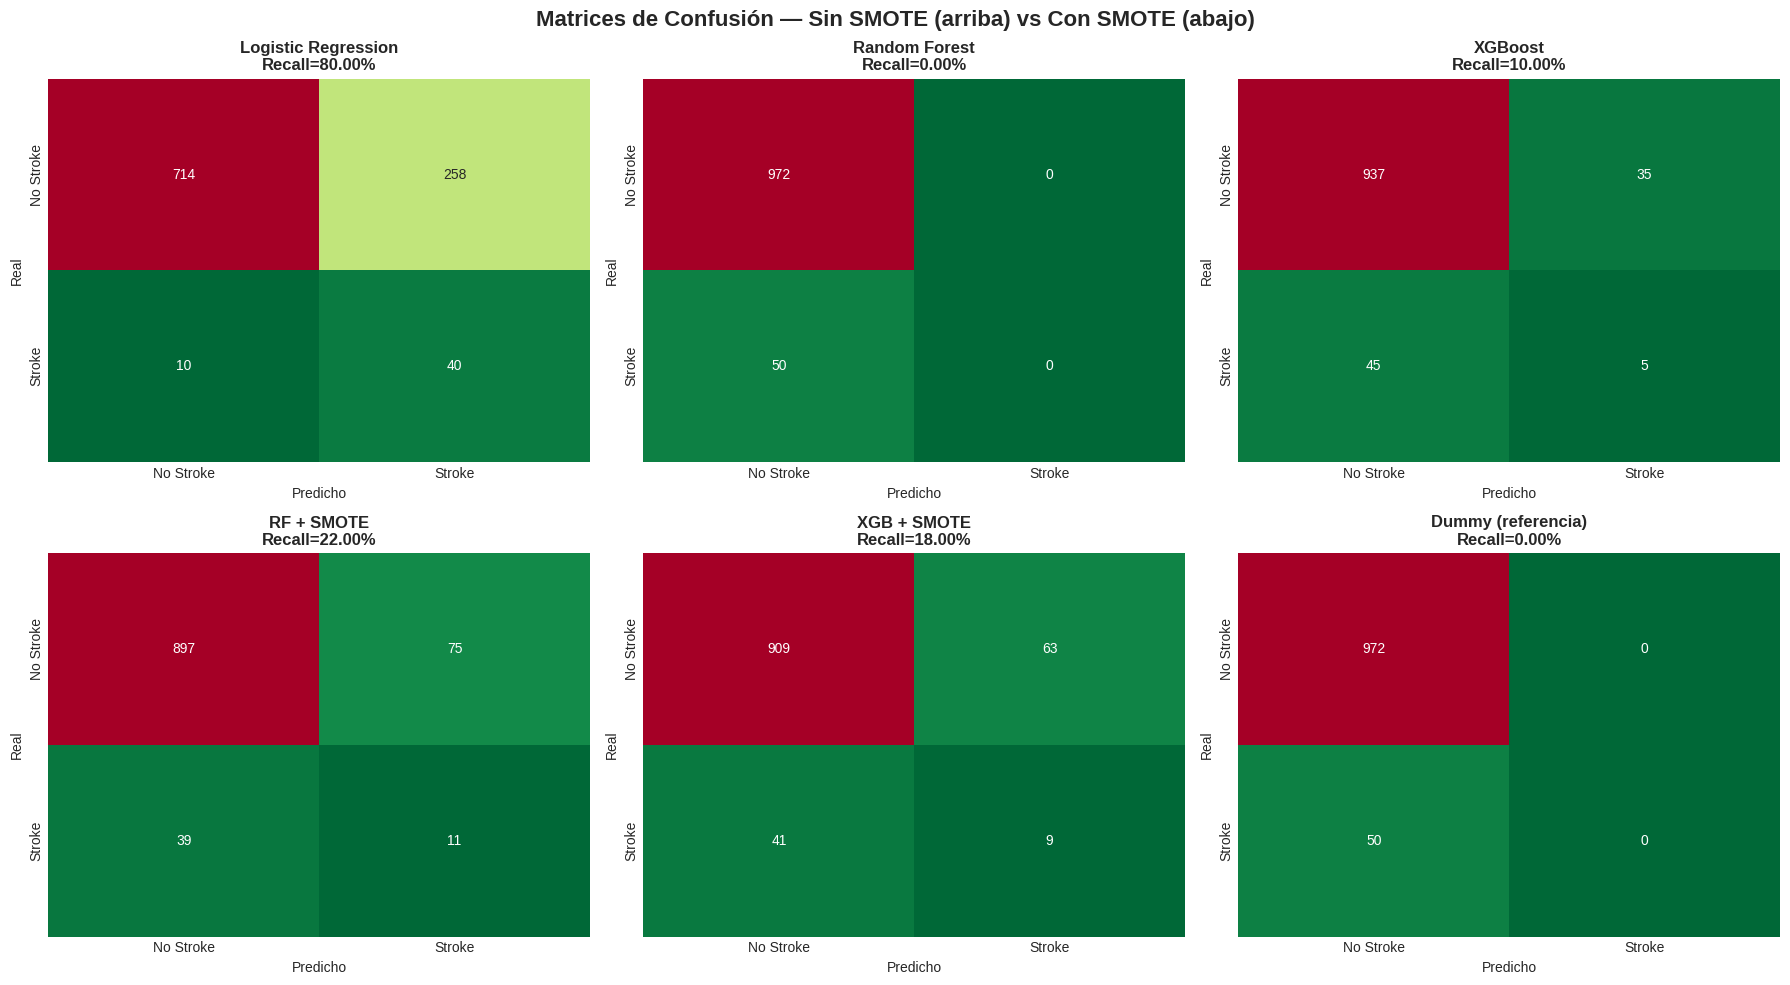

In [14]:
modelos_nombres = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "RF + SMOTE",
    "XGB + SMOTE",
    "Dummy (referencia)",
]
predicciones = [y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_rf_sm, y_pred_xgb_sm, y_pred_dummy]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Matrices de Confusión — Sin SMOTE (arriba) vs Con SMOTE (abajo)", fontsize=16, fontweight="bold")

for ax, nombre, y_pred in zip(axes.flatten(), modelos_nombres, predicciones):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="RdYlGn_r",
        xticklabels=["No Stroke", "Stroke"],
        yticklabels=["No Stroke", "Stroke"],
        ax=ax,
        cbar=False,
    )
    recall = recall_score(y_test, y_pred, zero_division=0)
    ax.set_title(f"{nombre}\nRecall={recall:.2%}", fontweight="bold")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")

plt.tight_layout()
plt.show()

## 9. Tabla comparativa

Ordenada por **Recall**. Porque aquí, recall = vidas.

In [15]:
resultados = []

modelos_eval = [
    ("Dummy", False, y_pred_dummy, dummy.predict_proba(X_test)[:, 1] if hasattr(dummy, "predict_proba") else np.zeros(len(y_test))),
    ("Logistic Regression", False, y_pred_lr, y_prob_lr),
    ("Random Forest", False, y_pred_rf, y_prob_rf),
    ("XGBoost", False, y_pred_xgb, y_prob_xgb),
    ("Random Forest", True, y_pred_rf_sm, y_prob_rf_sm),
    ("XGBoost", True, y_pred_xgb_sm, y_prob_xgb_sm),
]

for nombre, smote_flag, y_pred, y_prob in modelos_eval:
    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = 0.0
    resultados.append({
        "Modelo": nombre,
        "SMOTE": "Sí" if smote_flag else "No",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_stroke": precision_score(y_test, y_pred, zero_division=0),
        "Recall_stroke": recall_score(y_test, y_pred, zero_division=0),
        "F1_stroke": f1_score(y_test, y_pred, zero_division=0),
        "AUC_ROC": auc,
    })

df_resultados = pd.DataFrame(resultados).sort_values("Recall_stroke", ascending=False)
df_resultados = df_resultados.reset_index(drop=True)

# Formatear para display
df_display = df_resultados.copy()
for col in ["Accuracy", "Precision_stroke", "Recall_stroke", "F1_stroke", "AUC_ROC"]:
    df_display[col] = df_display[col].map("{:.3f}".format)

print("COMPARATIVA DE MODELOS — Ordenada por Recall")
print("=" * 80)
df_display

COMPARATIVA DE MODELOS — Ordenada por Recall


,Modelo,SMOTE,Accuracy,Precision_stroke,Recall_stroke,F1_stroke,AUC_ROC
0,Logistic Regression,No,0.738,0.134,0.800,0.230,0.839
1,Random Forest,Sí,0.888,0.128,0.220,0.162,0.761
2,XGBoost,Sí,0.898,0.125,0.180,0.148,0.745
3,XGBoost,No,0.922,0.125,0.100,0.111,0.750
4,Dummy,No,0.951,0.000,0.000,0.000,0.500
5,Random Forest,No,0.951,0.000,0.000,0.000,0.777


## 10. Recall por modelo — Visualización

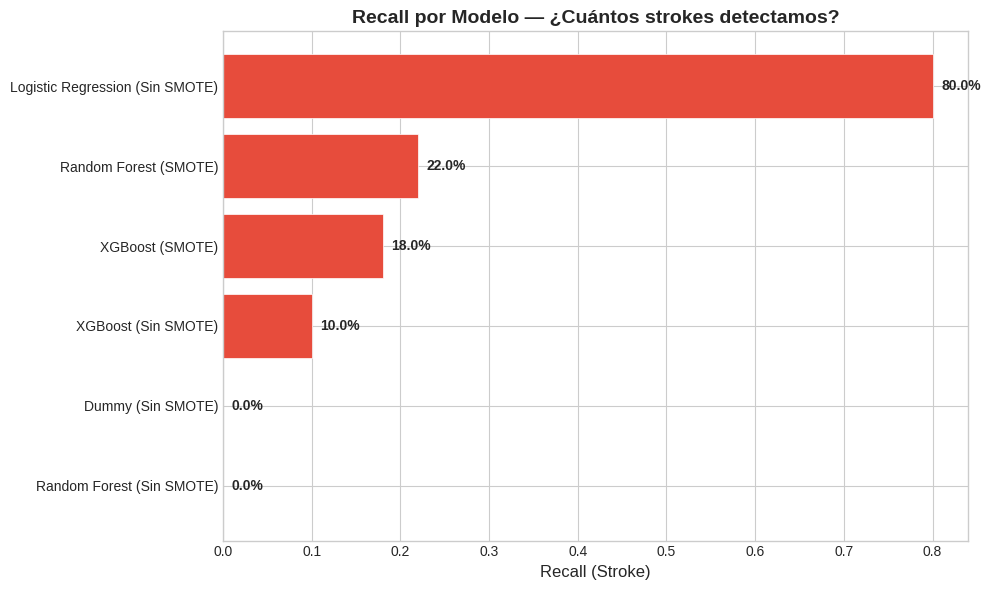

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

etiquetas = df_resultados["Modelo"] + " (" + df_resultados["SMOTE"].apply(lambda x: "SMOTE" if x == "Sí" else "Sin SMOTE") + ")"
recalls = df_resultados["Recall_stroke"].values
colores = [COLOR_SI if r > 0 else "#95a5a6" for r in recalls]

bars = ax.barh(range(len(etiquetas)), recalls, color=colores, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(etiquetas)))
ax.set_yticklabels(etiquetas)
ax.set_xlabel("Recall (Stroke)", fontsize=12)
ax.set_title("Recall por Modelo — ¿Cuántos strokes detectamos?", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.5)

for i, (bar, val) in enumerate(zip(bars, recalls)):
    ax.text(val + 0.01, i, f"{val:.1%}", va="center", fontweight="bold")

ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Importancia de features — Top 15

¿Qué variables usan los modelos para detectar strokes?

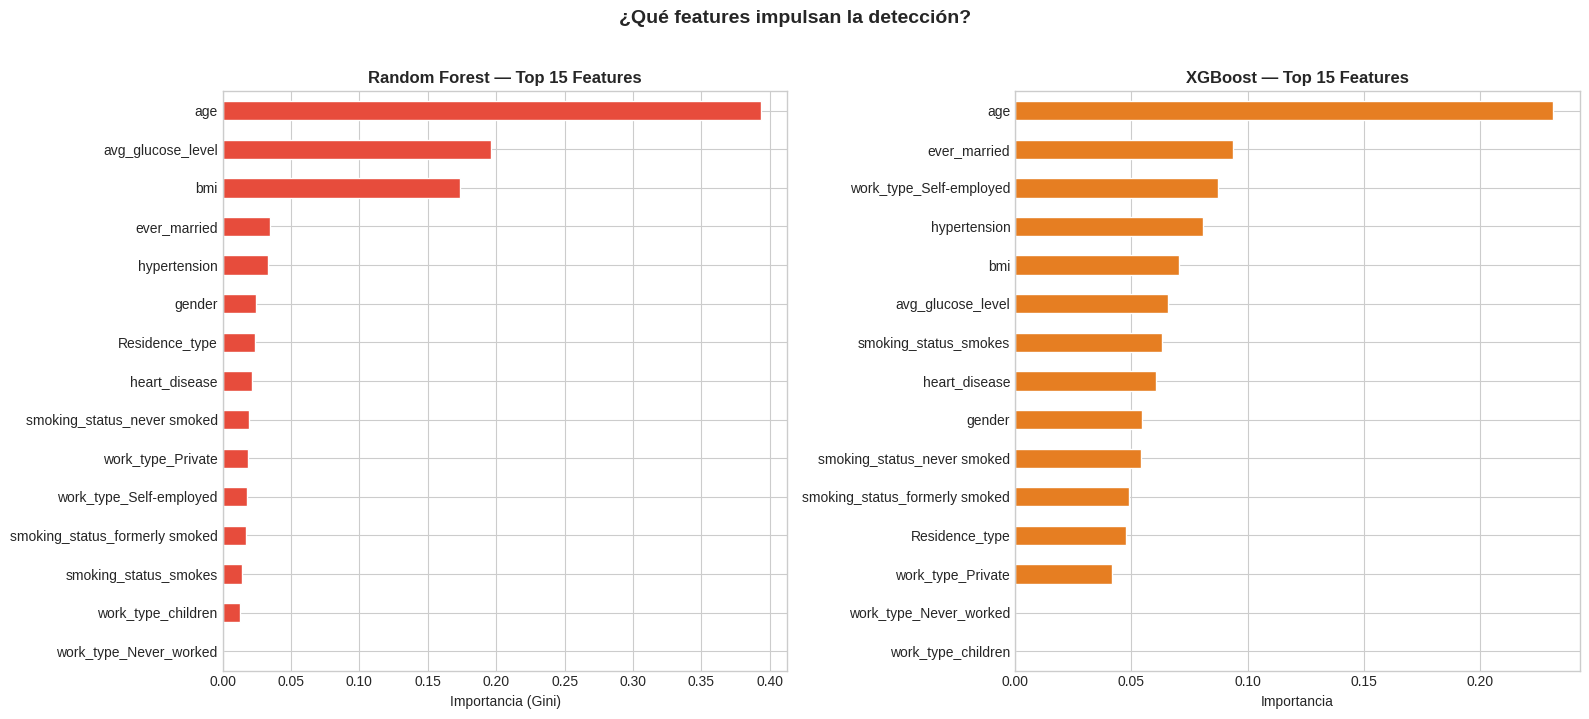

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
feat_imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
feat_imp_rf.plot(kind="barh", ax=axes[0], color=COLOR_SI, edgecolor="white")
axes[0].set_title("Random Forest — Top 15 Features", fontweight="bold")
axes[0].set_xlabel("Importancia (Gini)")

# XGBoost
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
feat_imp_xgb.plot(kind="barh", ax=axes[1], color="#e67e22", edgecolor="white")
axes[1].set_title("XGBoost — Top 15 Features", fontweight="bold")
axes[1].set_xlabel("Importancia")

plt.suptitle("¿Qué features impulsan la detección?", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 12. Guardar modelos

In [18]:
modelos_guardar = {
    "dummy_baseline.pkl": dummy,
    "logistic_regression_balanced.pkl": lr,
    "random_forest_balanced.pkl": rf,
    "xgboost_weighted.pkl": xgb,
    "random_forest_smote.pkl": rf_sm,
    "xgboost_smote.pkl": xgb_sm,
}

for nombre_archivo, modelo in modelos_guardar.items():
    ruta = os.path.join(models_dir, nombre_archivo)
    joblib.dump(modelo, ruta)
    print(f"Guardado: {ruta}")

print(f"\n{len(modelos_guardar)} modelos guardados en {models_dir}")

Guardado: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/dummy_baseline.pkl
Guardado: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/logistic_regression_balanced.pkl
Guardado: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/random_forest_balanced.pkl
Guardado: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/xgboost_weighted.pkl
Guardado: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/random_forest_smote.pkl
Guardado: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/xgboost_smote.pkl

6 modelos guardados en /home/danielmf31/Documentos/Documentos_Trabajo/Ingenie

In [19]:
# Guardar también la tabla de resultados
df_resultados.to_csv(os.path.join(models_dir, "comparativa_baselines.csv"), index=False)
print("Tabla comparativa guardada.")

Tabla comparativa guardada.


## 13. Resumen

**Hallazgos clave:**

In [20]:
best_row = df_resultados.iloc[0]
best_recall = best_row["Recall_stroke"]
best_name = best_row["Modelo"]
best_smote = best_row["SMOTE"]

print("=" * 60)
print("RESUMEN — Primer Diagnóstico")
print("=" * 60)
print(f"\nMejor modelo por Recall: {best_name} (SMOTE={best_smote})")
print(f"Recall: {best_recall:.1%}")
print(f"\nEl dummy tenía 0% recall. Ahora detectamos {best_recall:.1%} de los strokes.")
print(f"No es perfecto, pero es WAY better que el dummy.")
print(f"\nSiguiente paso: autopsia de errores (¿a quién fallamos?) y")
print(f"optimización de umbral (¿podemos salvar más vidas bajando el threshold?)")

RESUMEN — Primer Diagnóstico

Mejor modelo por Recall: Logistic Regression (SMOTE=No)
Recall: 80.0%

El dummy tenía 0% recall. Ahora detectamos 80.0% de los strokes.
No es perfecto, pero es WAY better que el dummy.

Siguiente paso: autopsia de errores (¿a quién fallamos?) y
optimización de umbral (¿podemos salvar más vidas bajando el threshold?)
